In [1]:
import os
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
DATASET_PATH = 'Emotion_data'

In [4]:
def load_ck_images(dataset_path):
    data, labels = [], []
    for emotion in os.listdir(dataset_path):
        emotion_path = os.path.join(dataset_path, emotion)
        if not os.path.isdir(emotion_path):
            continue
        for img_file in os.listdir(emotion_path):
            img_path = os.path.join(emotion_path, img_file)
            image = cv2.imread(img_path)
            image = cv2.resize(image, (96, 96))
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            data.append(image)
            labels.append(emotion)
    return np.array(data), np.array(labels)

In [5]:
X, y = load_ck_images(DATASET_PATH)

In [6]:
X = X.astype("float") / 255.0
X = X.reshape((X.shape[0], 96, 96, 1))

In [7]:
lb = LabelBinarizer()
y = lb.fit_transform(y)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [9]:
aug = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

In [10]:
model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(96, 96, 1)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(lb.classes_), activation='softmax')
])

C:\Users\dsair\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [13]:
history = model.fit(
    aug.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    steps_per_epoch=len(X_train) // 32,
    epochs=250,
    verbose=1
)

Epoch 1/250
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 385ms/step - accuracy: 0.4136 - loss: 1.5935 - val_accuracy: 0.1878 - val_loss: 2.2403
Epoch 2/250
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3750 - loss: 1.6663 - val_accuracy: 0.2081 - val_loss: 2.2726
Epoch 3/250
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 378ms/step - accuracy: 0.4423 - loss: 1.5520 - val_accuracy: 0.2284 - val_loss: 1.9178
Epoch 4/250
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2188 - loss: 1.5825 - val_accuracy: 0.2589 - val_loss: 1.9088
Epoch 5/250
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 380ms/step - accuracy: 0.4308 - loss: 1.4639 - val_accuracy: 0.2690 - val_loss: 1.7383
Epoch 6/250
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4375 - loss: 1.4807 - val_accuracy: 0.2589 - val_loss: 1.7607
Epoch 7/250
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 463ms/step - accuracy: 0.4321 - loss: 1.3993 - val_accuracy: 0.1371 - val_loss: 2.0239
Epoch 8/250
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5312 - loss: 1.3446 - val_accurac

In [14]:
loss, acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {acc * 100:.2f}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7375 - loss: 1.3018

Test Accuracy: 71.07%


In [16]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step


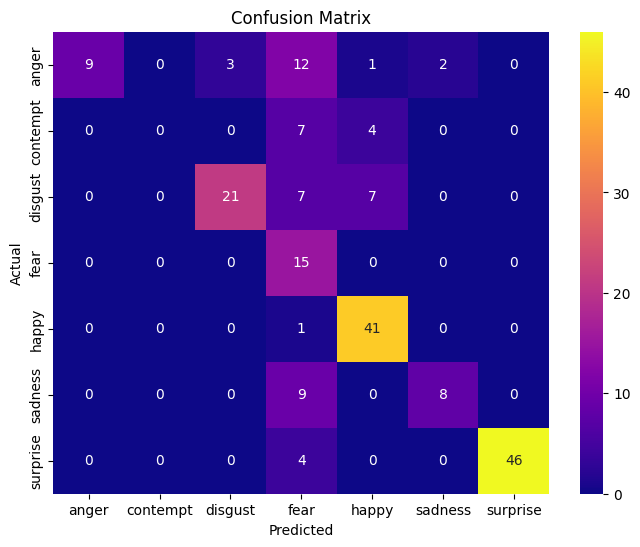

In [17]:
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='plasma', fmt='d', xticklabels=lb.classes_, yticklabels=lb.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print("\n Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=lb.classes_))


📊 Classification Report:

              precision    recall  f1-score   support

       anger       1.00      0.33      0.50        27
    contempt       0.00      0.00      0.00        11
     disgust       0.88      0.60      0.71        35
        fear       0.27      1.00      0.43        15
       happy       0.77      0.98      0.86        42
     sadness       0.80      0.47      0.59        17
    surprise       1.00      0.92      0.96        50

    accuracy                           0.71       197
   macro avg       0.67      0.61      0.58       197
weighted avg       0.80      0.71      0.71       197



C:\Users\dsair\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\dsair\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\dsair\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

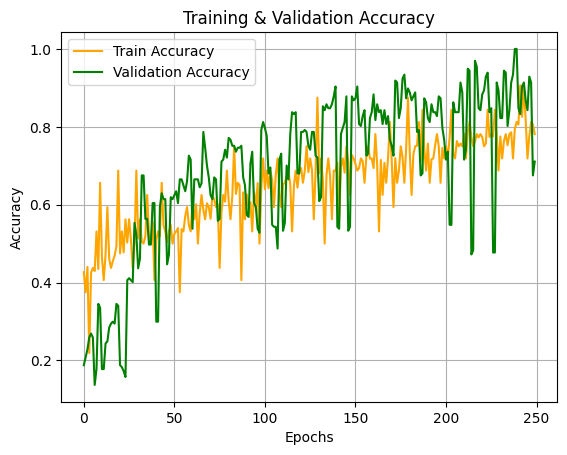

In [19]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy', color='orange')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='green')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
model.save("emotion_model_ckplus.keras")